In [3]:
import json
import pandas as pd
import re

with open("data/raw/dev.json") as f:
    data = json.load(f)

def flatten_example(ex: dict) -> dict:
    qa = ex["qa"]
    program = qa.get("program", "")
    # pull out operation names like divide, subtract, add, multiply, table_sum, greater...
    ops = re.findall(r"([a-z_]+)\(", program)

    return {
        "id": ex["id"],
        "filename": ex.get("filename", ""),
        "n_pre_text_lines": len(ex["pre_text"]),
        "n_post_text_lines": len(ex["post_text"]),
        "n_table_rows": len(ex["table"]),
        "n_table_cols": len(ex["table"][0]) if ex["table"] else 0,
        "question": qa["question"],
        "question_word_len": len(qa["question"].split()),
        "answer": qa.get("answer", ""),
        "exe_ans": qa.get("exe_ans", None),
        "program": program,
        "n_ops": len(ops),
        "ops": ops,
        "n_gold_table_rows": len(qa.get("ann_table_rows", [])),
        "n_gold_text_rows": len(qa.get("ann_text_rows", [])),
    }

df = pd.DataFrame([flatten_example(ex) for ex in data])
print(df.shape)
df.head()

(883, 15)


,id,filename,n_pre_text_lines,n_post_text_lines,n_table_rows,n_table_cols,question,question_word_len,answer,exe_ans,program,n_ops,ops,n_gold_table_rows,n_gold_text_rows
0,V/2008/page_17.pdf-1,V/2008/page_17.pdf,44,21,7,5,what is the average payment volume per transac...,11,127.40,127.4,"divide(637, const_5)",1,[divide],1,0
1,C/2017/page_328.pdf-1,C/2017/page_328.pdf,3,1,7,4,what was the percentage cumulative total retur...,18,93.5%,0.935,"subtract(193.5, const_100), divide(#0, const_100)",2,"[subtract, divide]",2,0
2,DVN/2007/page_58.pdf-2,DVN/2007/page_58.pdf,35,1,6,5,what percentage of the total oil and gas mmboe...,12,24.69%,24.69136,"divide(60, 243), multiply(#0, const_100)",2,"[divide, multiply]",2,1
3,ETR/2011/page_341.pdf-3,ETR/2011/page_341.pdf,4,9,5,2,in 2010 what was the net change in net revenue...,12,18.6,19.2,"add(18.9, 0.3)",1,[add],2,0
4,ETR/2004/page_213.pdf-2,ETR/2004/page_213.pdf,7,6,8,2,what are the deferred fuel cost revisions as a...,18,60.3%,0.60306,"divide(59.1, 98.0)",1,[divide],1,2


In [ ]:
df["question"][0]

'what is the average payment volume per transaction for american express?'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 883 entries, 0 to 882
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 883 non-null    object
 1   filename           883 non-null    object
 2   n_pre_text_lines   883 non-null    int64 
 3   n_post_text_lines  883 non-null    int64 
 4   n_table_rows       883 non-null    int64 
 5   n_table_cols       883 non-null    int64 
 6   question           883 non-null    object
 7   question_word_len  883 non-null    int64 
 8   answer             883 non-null    object
 9   exe_ans            883 non-null    object
 10  program            883 non-null    object
 11  n_ops              883 non-null    int64 
 12  ops                883 non-null    object
 13  n_gold_table_rows  883 non-null    int64 
 14  n_gold_text_rows   883 non-null    int64 
dtypes: int64(8), object(7)
memory usage: 103.6+ KB


In [ ]:
def clean_text(text: str) -> str:
    """Fix FinQA tokenization artifacts around punctuation and parentheses."""
    # "( billions )" -> "(billions)", "( 1 )" -> "(1)"
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s+\)", ")", text)
    # "2007 :" -> "2007:", "inc ." -> "inc."
    text = re.sub(r"\s+([.,;:!?])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample = data[0]["pre_text"][3]
print("before:", sample)
print("after: ", clean_text(sample))


before: the following chart compares our network with those of our major competitors for calendar year 2007 : company payments volume volume transactions cards ( billions ) ( billions ) ( billions ) ( millions ) visa inc. ( 1 ) .
after:  the following chart compares our network with those of our major competitors for calendar year 2007: company payments volume volume transactions cards (billions) (billions) (billions) (millions) visa inc. (1).


In [4]:
import json
with open('data/raw/dev.json') as f:
    data = json.load(f)

# find lone-punctuation / near-empty lines
lone_punct = 0
very_short = 0
examples_lone = []
for ex in data:
    for line in ex['pre_text'] + ex['post_text']:
        stripped = line.strip()
        if stripped in {'.', ',', ';', ':', '-'}:
            lone_punct += 1
            if len(examples_lone) < 5:
                examples_lone.append((ex['id'], line))
        elif len(stripped.split()) <= 2:
            very_short += 1

print('lone punctuation-only lines:', lone_punct)
print('very short lines (<=2 words):', very_short)
print('sample lone punct lines:', examples_lone)

# check empty tables
empty_tables = sum(1 for ex in data if not ex['table'] or len(ex['table']) <= 1)
print('examples with empty/header-only table:', empty_tables)

# check duplicate consecutive lines
dup_count = 0
for ex in data:
    lines = ex['pre_text']
    for i in range(1, len(lines)):
        if lines[i] == lines[i-1]:
            dup_count += 1
print('duplicate consecutive pre_text lines:', dup_count)

lone punctuation-only lines: 944
very short lines (<=2 words): 348
sample lone punct lines: [('V/2008/page_17.pdf-1', '.'), ('V/2008/page_17.pdf-1', '.'), ('V/2008/page_17.pdf-1', '.'), ('V/2008/page_17.pdf-1', '.'), ('V/2008/page_17.pdf-1', '.')]
examples with empty/header-only table: 0
duplicate consecutive pre_text lines: 313


In [5]:
spaced_paren = 0
spaced_dollar = 0
for ex in data:
    for line in ex['pre_text'] + ex['post_text']:
        if re.search(r'\( \d', line) or re.search(r'\d \)', line):
            spaced_paren += 1
        if re.search(r'\\\$ \d', line):
            spaced_dollar += 1

print('lines with spaced parentheses around numbers:', spaced_paren)
print('lines with spaced dollar signs:', spaced_dollar)
print()
print('example:', data[0]['pre_text'][3])

lines with spaced parentheses around numbers: 1864
lines with spaced dollar signs: 0

example: the following chart compares our network with those of our major competitors for calendar year 2007 : company payments volume volume transactions cards ( billions ) ( billions ) ( billions ) ( millions ) visa inc. ( 1 ) .


In [6]:
from collections import Counter

ops_counter = Counter()
for ex in data:
    program = ex['qa'].get('program', '')
    ops = re.findall(r'([a-z_]+)\(', program)
    ops_counter.update(ops)

print('Operation frequency:')
for op, cnt in ops_counter.most_common():
    print(f'  {op}: {cnt}')

gold_table = [len(ex['qa'].get('ann_table_rows', [])) for ex in data]
gold_text = [len(ex['qa'].get('ann_text_rows', [])) for ex in data]
print()
print('avg gold table rows used:', sum(gold_table)/len(gold_table))
print('avg gold text rows used:', sum(gold_text)/len(gold_text))
print('% examples using ONLY table (no text):', sum(1 for t,x in zip(gold_table,gold_text) if t>0 and x==0)/len(data)*100)


Operation frequency:
  divide: 636
  subtract: 416
  add: 180
  multiply: 83
  table_average: 19
  greater: 10
  table_max: 8
  table_min: 5
  table_sum: 4
  exp: 1

avg gold table rows used: 1.087202718006795
avg gold text rows used: 0.4258210645526614
% examples using ONLY table (no text): 57.07814269535674


In [7]:
df["program"].value_counts()

program
table_average(net sales, none)                        4
divide(15, 37)                                        2
subtract(99832, 81881), divide(#0, 81881)             2
divide(634203, 1848575)                               2
add(13536, 4091), add(#0, 1031), divide(#1, 19427)    2
                                                     ..
divide(1486, 44572)                                   1
add(105, 67)                                          1
divide(988.1, 4111.8)                                 1
divide(5.4, 47.1)                                     1
divide(4717, 7680)                                    1
Name: count, Length: 857, dtype: int64

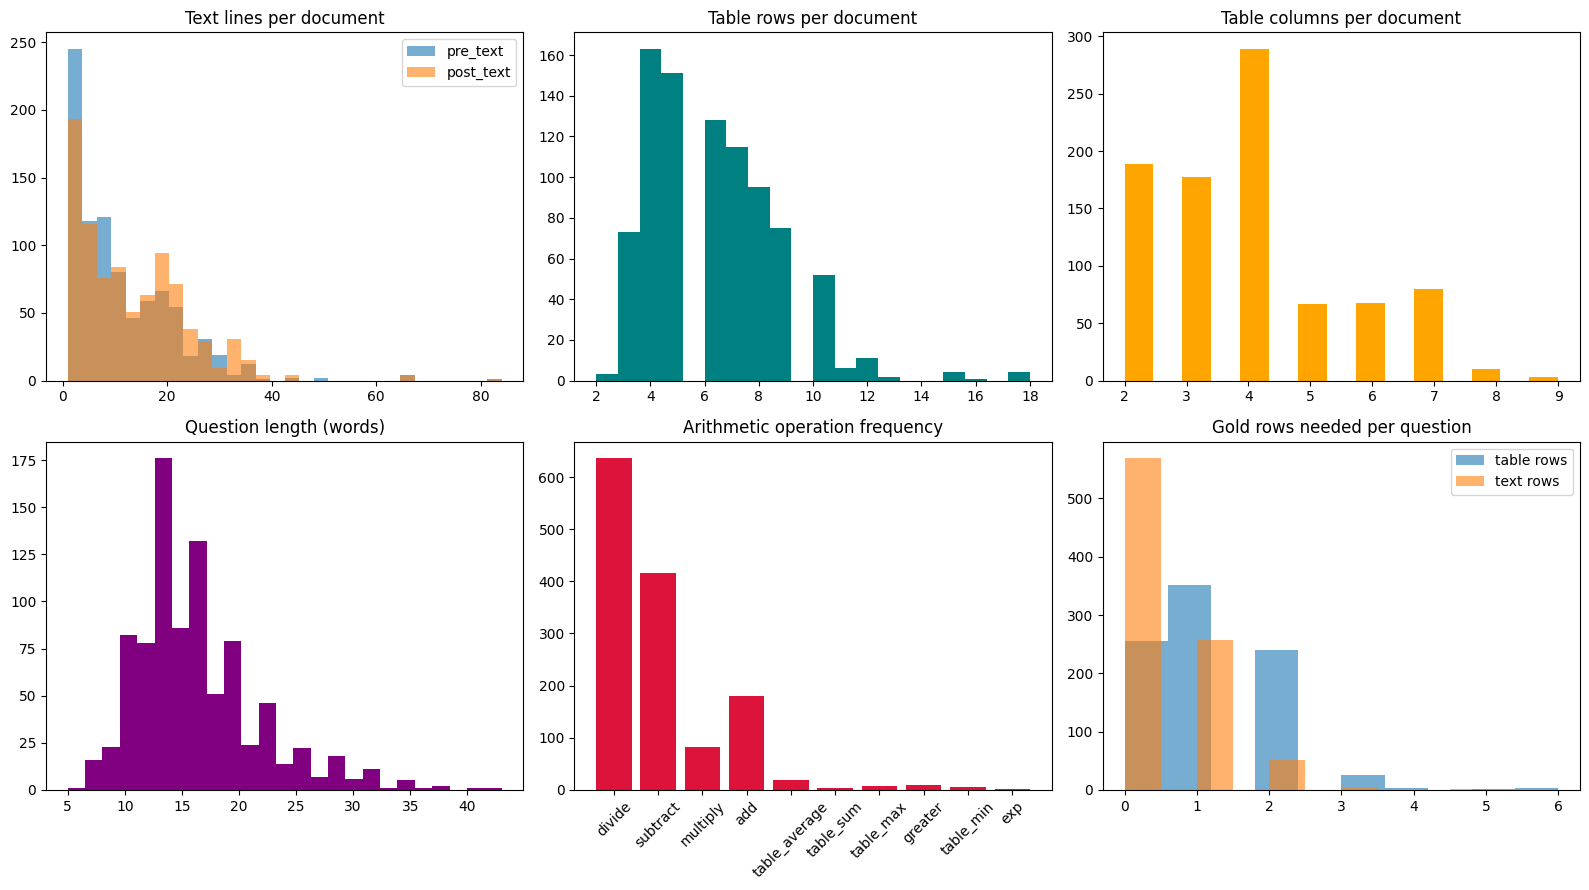

In [8]:
import matplotlib.pyplot as plt
from collections import Counter
import re

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. pre/post text line counts per doc
axes[0, 0].hist(df["n_pre_text_lines"], bins=30, alpha=0.6, label="pre_text")
axes[0, 0].hist(df["n_post_text_lines"], bins=30, alpha=0.6, label="post_text")
axes[0, 0].set_title("Text lines per document")
axes[0, 0].legend()

# 2. table shape
axes[0, 1].hist(df["n_table_rows"], bins=20, color="teal")
axes[0, 1].set_title("Table rows per document")

axes[0, 2].hist(df["n_table_cols"], bins=15, color="orange")
axes[0, 2].set_title("Table columns per document")

# 3. question length
axes[1, 0].hist(df["question_word_len"], bins=25, color="purple")
axes[1, 0].set_title("Question length (words)")

# 4. operation frequency (the arithmetic ops the model must perform)
all_ops = [op for ops in df["ops"] for op in ops]
op_counts = Counter(all_ops)
axes[1, 1].bar(op_counts.keys(), op_counts.values(), color="crimson")
axes[1, 1].set_title("Arithmetic operation frequency")
axes[1, 1].tick_params(axis="x", rotation=45)

# 5. retrieval complexity: how many gold table/text rows does each question need?
axes[1, 2].hist(df["n_gold_table_rows"], bins=10, alpha=0.6, label="table rows")
axes[1, 2].hist(df["n_gold_text_rows"], bins=10, alpha=0.6, label="text rows")
axes[1, 2].set_title("Gold rows needed per question")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

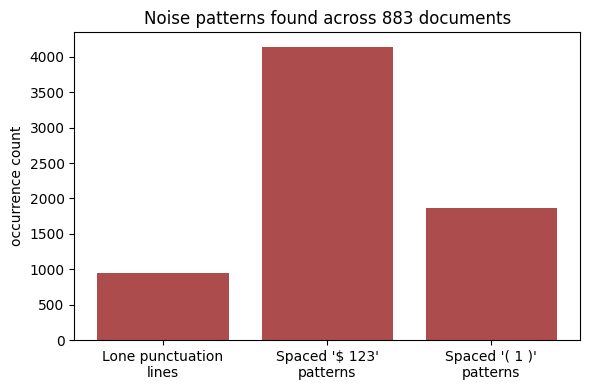

In [9]:
import re

lone_punct_count, spaced_dollar_count, spaced_paren_count = 0, 0, 0
for ex in data:
    for line in ex["pre_text"] + ex["post_text"]:
        stripped = line.strip()
        if stripped in {".", ",", ";", ":", "-"}:
            lone_punct_count += 1
        if re.search(r"\$ \d", line):
            spaced_dollar_count += 1
        if re.search(r"\( \d", line) or re.search(r"\d \)", line):
            spaced_paren_count += 1

noise_labels = ["Lone punctuation\nlines", "Spaced '$ 123'\npatterns", "Spaced '( 1 )'\npatterns"]
noise_counts = [lone_punct_count, spaced_dollar_count, spaced_paren_count]

plt.figure(figsize=(6, 4))
plt.bar(noise_labels, noise_counts, color="darkred", alpha=0.7)
plt.title(f"Noise patterns found across {len(data)} documents")
plt.ylabel("occurrence count")
plt.tight_layout()
plt.show()

In [10]:
import re

def clean_line(line: str) -> str:
    """Fix tokenization spacing artifacts without touching numeric content."""
    line = re.sub(r"\$\s+(\d)", r"$\1", line)        # "$ 2457" -> "$2457"
    line = re.sub(r"\(\s+(\d)", r"(\1", line)
    line = re.sub(r"\(\s+", "(", line)   # "( billions" -> "(billions"
    line = re.sub(r"\s+\)", ")", line)   # "billions )" -> "billions)"         # "( 1 )"  -> "(1)"
    
    line = re.sub(r"(\d)\s+\)", r"\1)", line)
    line = re.sub(r"\s+([.,;:%])", r"\1", line)       # "50.3 %" -> "50.3%"  (space before punctuation)
    line = re.sub(r"\s{2,}", " ", line).strip()       # collapse double spaces
    return line

def is_noise_line(line: str) -> bool:
    """Flag lone-punctuation / near-empty lines for removal."""
    stripped = line.strip()
    return stripped in {".", ",", ";", ":", "-", ""}

def clean_text_lines(lines: list[str]) -> list[str]:
    cleaned = []
    prev = None
    for line in lines:
        if is_noise_line(line):
            continue                    # drop junk lines
        if line == prev:
            continue                    # drop exact duplicates
        cleaned.append(clean_line(line))
        prev = line
    return cleaned

# quick before/after check on example 0
raw = data[2]["pre_text"]
cleaned = clean_text_lines(raw)
print("before:", len(raw), "lines ->", "after:", len(cleaned), "lines")
print()
print("sample cleaned line:", cleaned[3])

before: 35 lines -> after: 35 lines

sample cleaned line: in december 2007, the fasb also issued statement of financial accounting standards no.


In [11]:
883 - df["filename"].duplicated().sum()

299

In [14]:
filenames = [ex['filename'] for ex in data]
unique_filenames = set(filenames)
print('total QA examples:', len(data))
print('unique filenames (source pages):', len(unique_filenames))
print()

# check if same filename => identical pre_text/table/post_text
from collections import defaultdict
by_file = defaultdict(list)
for ex in data:
    by_file[ex['filename']].append(ex)
    
dupes = {f: exs for f, exs in by_file.items() if len(exs) > 1}
print('filenames with multiple QA examples:', len(dupes))

# spot check: is the underlying doc content actually identical?
sample_fname = list(dupes.keys())[0]
exs = dupes[sample_fname]
print('sample filename:', sample_fname, '-> ', len(exs), 'questions')
print('pre_text identical across all?', all(e['pre_text']==exs[0]['pre_text'] for e in exs))
print('table identical across all?', all(e['table']==exs[0]['table'] for e in exs))
print('questions:', [e['qa']['question'] for e in exs])

total QA examples: 883
unique filenames (source pages): 299

filenames with multiple QA examples: 272
sample filename: V/2008/page_17.pdf ->  2 questions
pre_text identical across all? True
table identical across all? True
questions: ['what is the average payment volume per transaction for american express?', 'what is the average payment volume per transaction for jcb?']


In [ ]:
ex = data[0]
print('table (normalized):')
for row in ex['table'][:3]:
    print(row)
print()
print('table_ori (original):')
for row in ex['table_ori'][:3]:
    print(row)

table (normalized):
['company', 'payments volume ( billions )', 'total volume ( billions )', 'total transactions ( billions )', 'cards ( millions )']
['visa inc. ( 1 )', '$ 2457', '$ 3822', '50.3', '1592']
['mastercard', '1697', '2276', '27.0', '916']

table_ori (original):
['Company', 'Payments Volume  (billions)', 'Total Volume  (billions)<i></i>', 'Total Transactions  (billions)', '<i></i> Cards  (millions)']
['Visa Inc.<sup>(1)</sup>', '$2,457', '$3,822', '50.3<i></i>', '1,592']
['MasterCard', '1,697', '2,276', '27.0', '916']


In [ ]:
html_cell_count = 0
total_cells = 0
for ex in data:
    for row in ex['table_ori']:
        for cell in row:
            total_cells += 1
            if re.search(r'<[^>]+>', cell):
                html_cell_count += 1

print(f'{html_cell_count} / {total_cells} table_ori cells contain HTML tags ({html_cell_count/total_cells*100:.1f}%)')

576 / 21232 table_ori cells contain HTML tags (2.7%)


In [ ]:
by_file = defaultdict(list)
for ex in data:
    by_file[ex['filename']].append(ex)

print('unique docs:', len(by_file))
print('total qa pairs still accounted for:', sum(len(v) for v in by_file.values()))

unique docs: 299
total qa pairs still accounted for: 883


In [ ]:
import json
import os
import re
from collections import defaultdict

def strip_html(cell: str) -> str:
    """Remove leftover HTML tags like <i></i>, <sup>(1)</sup>."""
    cell = re.sub(r"<[^>]+>", "", cell)
    return re.sub(r"\s{2,}", " ", cell).strip()

def clean_table(table_ori: list[list[str]]) -> list[list[str]]:
    return [[strip_html(cell) for cell in row] for row in table_ori]

def table_to_markdown(table: list[list[str]]) -> str:
    """Render a cleaned table as a markdown table string."""
    if not table:
        return ""
    header, *rows = table
    md = "| " + " | ".join(header) + " |\n"
    md += "| " + " | ".join(["---"] * len(header)) + " |\n"
    for row in rows:
        md += "| " + " | ".join(row) + " |\n"
    return md

def build_document(filename: str, examples: list[dict]) -> dict:
    """One QA example's worth of pre_text/table/post_text is identical
    across all examples sharing this filename — use the first one."""
    ex = examples[0]

    pre_text_clean = clean_text_lines(ex["pre_text"])     # from Cell 4, last step
    post_text_clean = clean_text_lines(ex["post_text"])
    table_clean = clean_table(ex["table_ori"])
    table_md = table_to_markdown(table_clean)

    full_text = (
        " ".join(pre_text_clean)
        + "\n\n" + table_md + "\n"
        + " ".join(post_text_clean)
    )

    return {
        "doc_id": filename,
        "pre_text": pre_text_clean,
        "post_text": post_text_clean,
        "table": table_clean,
        "table_markdown": table_md,
        "full_text": full_text,
        "qa_ids": [e["id"] for e in examples],   # links back to every question this doc answers
    }

# --- run reconstruction over all 299 unique docs ---
by_file = defaultdict(list)
for ex in data:
    by_file[ex["filename"]].append(ex)

documents = [build_document(fname, exs) for fname, exs in by_file.items()]

print(f"reconstructed {len(documents)} documents")

# inspect one
doc = documents[0]
print("\n--- doc_id ---")
print(doc["doc_id"])
print("\n--- qa_ids attached to this doc ---")
print(doc["qa_ids"])
print("\n--- full_text preview ---")
print(doc["full_text"][:600])

# save to disk for the next step
os.makedirs("data/processed", exist_ok=True)
with open("data/processed/documents.jsonl", "w") as f:
    for d in documents:
        f.write(json.dumps(d) + "\n")

print("\nsaved to data/processed/documents.jsonl")

reconstructed 299 documents

--- doc_id ---
V/2008/page_17.pdf

--- qa_ids attached to this doc ---
['V/2008/page_17.pdf-1', 'V/2008/page_17.pdf-2']

--- full_text preview ---
largest operators of open-loop and closed-loop retail electronic payments networks the largest operators of open-loop and closed-loop retail electronic payments networks are visa, mastercard, american express, discover, jcb and diners club. with the exception of discover, which primarily operates in the united states, all of the other network operators can be considered multi- national or global providers of payments network services. based on payments volume, total volume, number of transactions and number of cards in circulation, visa is the largest retail electronic payments network in the 

saved to data/processed/documents.jsonl


In [ ]:
pd.read_json("data/processed/documents.jsonl", lines=True)

,doc_id,pre_text,post_text,table,table_markdown,full_text,qa_ids
0,V/2008/page_17.pdf,[largest operators of open-loop and closed-loo...,"[(1) visa inc., figures as reported previously...","[[Company, Payments Volume (billions), Total V...",| Company | Payments Volume (billions) | Total...,largest operators of open-loop and closed-loop...,"[V/2008/page_17.pdf-1, V/2008/page_17.pdf-2]"
1,C/2017/page_328.pdf,[performance graph comparison of five-year cum...,[],"[[DATE, CITI, S&P 500, S&P FINANCIALS], [31-De...",| DATE | CITI | S&P 500 | S&P FINANCIALS |\n| ...,performance graph comparison of five-year cumu...,"[C/2017/page_328.pdf-1, C/2017/page_328.pdf-4,..."
2,DVN/2007/page_58.pdf,[the acquisition date is on or after the begin...,[],"[[, Oil (MMBbls), Gas (Bcf), NGLs (MMBbls), To...",| | Oil (MMBbls) | Gas (Bcf) | NGLs (MMBbls) ...,the acquisition date is on or after the beginn...,"[DVN/2007/page_58.pdf-2, DVN/2007/page_58.pdf-3]"
3,ETR/2011/page_341.pdf,"[entergy mississippi, inc., management 2019s f...",[the volume/weather variance is primarily due ...,"[[, Amount (In Millions)], [2009 net revenue, ...",| | Amount (In Millions) |\n| --- | --- |\n| ...,"entergy mississippi, inc. management 2019s fin...","[ETR/2011/page_341.pdf-3, ETR/2011/page_341.pd..."
4,ETR/2004/page_213.pdf,"[entergy louisiana, inc., management's financi...",[the deferred fuel cost revisions variance res...,"[[, (In Millions)], [2002 net revenue, $922.9]...",| | (In Millions) |\n| --- | --- |\n| 2002 ne...,"entergy louisiana, inc. management's financial...","[ETR/2004/page_213.pdf-2, ETR/2004/page_213.pd..."
...,...,...,...,...,...,...,...
294,UNP/2014/page_75.pdf,"[the analysis of our depreciation studies., ch...",[],"[[Millions, Dec. 31, 2014, Dec. 31,2013], [Acc...","| Millions | Dec. 31, 2014 | Dec. 31,2013 |\n|...",the analysis of our depreciation studies. chan...,"[UNP/2014/page_75.pdf-1, UNP/2014/page_75.pdf-..."
295,MRO/2014/page_58.pdf,[outlook budget our board of directors approve...,[(a) represents the net budget after factoring...,"[[(In millions), 2015 Budget, Percent of Total...",| (In millions) | 2015 Budget | Percent of Tot...,outlook budget our board of directors approved...,[MRO/2014/page_58.pdf-1]
296,UA/2009/page_50.pdf,"[addition, we are exposed to gains and losses ...",[although we have entered into foreign currenc...,"[[Year Ended December 31,, ], [(In thousands),...","| Year Ended December 31, | |\n| --- | --- |\...","addition, we are exposed to gains and losses r...",[UA/2009/page_50.pdf-2]
297,BLK/2016/page_119.pdf,"[$239 million, respectively, at december 31, 2...","[long-term borrowings at december 31, 2015 had...","[[(in millions), MaturityAmount, Unamortized D...",| (in millions) | MaturityAmount | Unamortized...,"$239 million, respectively, at december 31, 20...","[BLK/2016/page_119.pdf-2, BLK/2016/page_119.pd..."


In [ ]:
ex = data[0]
print('question:', ex['qa']['question'])
print('ann_table_rows:', ex['qa'].get('ann_table_rows'))
print('ann_text_rows:', ex['qa'].get('ann_text_rows'))
print('gold_inds:', ex['qa'].get('gold_inds'))
print()
print('table row referenced by ann_table_rows index:')
idx = ex['qa'].get('ann_table_rows')
if idx:
    for i in idx:
        print(i, '->', ex['table_ori'][i])


question: what is the average payment volume per transaction for american express?
ann_table_rows: [3]
ann_text_rows: []
gold_inds: {'table_3': 'company the american express of payments volume ( billions ) is 637 ; the american express of total volume ( billions ) is 647 ; the american express of total transactions ( billions ) is 5.0 ; the american express of cards ( millions ) is 86 ;'}

table row referenced by ann_table_rows index:
3 -> ['American Express', '637', '647', '5.0', '86']


In [ ]:
# Overview tables: raw QA examples vs processed documents
import pandas as pd

raw_rows = []
for ex in data:
    qa = ex["qa"]
    raw_rows.append({
        "id": ex["id"],
        "filename": ex["filename"],
        "n_pre_text": len(ex["pre_text"]),
        "n_post_text": len(ex["post_text"]),
        "table_shape": f"{len(ex['table'])}x{len(ex['table'][0]) if ex['table'] else 0}",
        "question": qa["question"],
        "answer": qa.get("answer"),
        "program": qa.get("program"),
        "n_gold_table_rows": len(qa.get("ann_table_rows", [])),
        "n_gold_text_rows": len(qa.get("ann_text_rows", [])),
    })
raw_df = pd.DataFrame(raw_rows)

doc_rows = []
for d in documents:
    doc_rows.append({
        "doc_id": d["doc_id"],
        "n_pre_text": len(d["pre_text"]),
        "n_post_text": len(d["post_text"]),
        "table_shape": f"{len(d['table'])}x{len(d['table'][0]) if d['table'] else 0}",
        "n_questions": len(d["qa_ids"]),
        "full_text_words": len(d["full_text"].split()),
        "qa_ids": ", ".join(d["qa_ids"]),
    })
docs_df = pd.DataFrame(doc_rows)

print("BEFORE FILTERING — one row = one question (dev.json)")
print(f"{len(raw_df)} questions on {raw_df['filename'].nunique()} unique pages")
display(raw_df.head(10))

print("\nAFTER FILTERING — one row = one unique page (documents.jsonl)")
print(f"{len(docs_df)} documents, {int(docs_df['n_questions'].sum())} questions still linked via qa_ids")
display(docs_df.head(10))


BEFORE FILTERING — one row = one question (dev.json)
883 questions on 299 unique pages


,id,filename,n_pre_text,n_post_text,table_shape,question,answer,program,n_gold_table_rows,n_gold_text_rows
0,V/2008/page_17.pdf-1,V/2008/page_17.pdf,44,21,7x5,what is the average payment volume per transac...,127.40,"divide(637, const_5)",1,0
1,C/2017/page_328.pdf-1,C/2017/page_328.pdf,3,1,7x4,what was the percentage cumulative total retur...,93.5%,"subtract(193.5, const_100), divide(#0, const_100)",2,0
2,DVN/2007/page_58.pdf-2,DVN/2007/page_58.pdf,35,1,6x5,what percentage of the total oil and gas mmboe...,24.69%,"divide(60, 243), multiply(#0, const_100)",2,1
3,ETR/2011/page_341.pdf-3,ETR/2011/page_341.pdf,4,9,5x2,in 2010 what was the net change in net revenue...,18.6,"add(18.9, 0.3)",2,0
4,ETR/2004/page_213.pdf-2,ETR/2004/page_213.pdf,7,6,8x2,what are the deferred fuel cost revisions as a...,60.3%,"divide(59.1, 98.0)",1,2
5,PM/2017/page_38.pdf-1,PM/2017/page_38.pdf,7,17,4x5,what was the change in millions of operating i...,688,"subtract(11503, 10815)",1,0
6,JPM/2008/page_85.pdf-3,JPM/2008/page_85.pdf,27,3,6x3,what was jpmorgan chase & co's common equity t...,10.94%,"divide(136104, 1244659)",2,0
7,PNC/2013/page_207.pdf-1,PNC/2013/page_207.pdf,8,13,4x7,"at the end of 2014 , the notional value of der...",3044%,"divide(36197, 1189)",1,0
8,CME/2017/page_97.pdf-5,CME/2017/page_97.pdf,3,25,7x3,what was the increase in class a common stock ...,995,"subtract(339235, 338240)",1,0
9,PNC/2013/page_62.pdf-2,PNC/2013/page_62.pdf,14,17,9x3,in millions what was total residential mortgag...,3576,"add(1356, 2220)",1,0



AFTER FILTERING — one row = one unique page (documents.jsonl)
299 documents, 883 questions still linked via qa_ids


,doc_id,n_pre_text,n_post_text,table_shape,n_questions,full_text_words,qa_ids
0,V/2008/page_17.pdf,5,21,7x5,2,564,"V/2008/page_17.pdf-1, V/2008/page_17.pdf-2"
1,C/2017/page_328.pdf,3,0,7x4,4,193,"C/2017/page_328.pdf-1, C/2017/page_328.pdf-4, ..."
2,DVN/2007/page_58.pdf,35,0,6x5,2,674,"DVN/2007/page_58.pdf-2, DVN/2007/page_58.pdf-3"
3,ETR/2011/page_341.pdf,4,9,5x2,3,425,"ETR/2011/page_341.pdf-3, ETR/2011/page_341.pdf..."
4,ETR/2004/page_213.pdf,7,6,8x2,4,434,"ETR/2004/page_213.pdf-2, ETR/2004/page_213.pdf..."
5,PM/2017/page_38.pdf,7,17,5x3,4,560,"PM/2017/page_38.pdf-1, PM/2017/page_38.pdf-3, ..."
6,JPM/2008/page_85.pdf,27,3,6x3,5,863,"JPM/2008/page_85.pdf-3, JPM/2008/page_85.pdf-4..."
7,PNC/2013/page_207.pdf,8,13,5x3,2,572,"PNC/2013/page_207.pdf-1, PNC/2013/page_207.pdf-2"
8,CME/2017/page_97.pdf,3,25,8x2,5,673,"CME/2017/page_97.pdf-5, CME/2017/page_97.pdf-4..."
9,PNC/2013/page_62.pdf,14,17,9x3,2,816,"PNC/2013/page_62.pdf-2, PNC/2013/page_62.pdf-1"


In [ ]:
for ex in data:
    rows = ex['qa'].get('ann_text_rows', [])
    if rows:
        print('question:', ex['qa']['question'])
        print('ann_text_rows:', rows)
        print('pre_text len:', len(ex['pre_text']), '| post_text len:', len(ex['post_text']))
        idx = rows[0]
        if idx < len(ex['pre_text']):
            print('indexes into pre_text:', ex['pre_text'][idx])
        else:
            print('indexes into post_text:', ex['post_text'][idx - len(ex['pre_text'])])
        break

question: what percentage of the total oil and gas mmboe comes from canada?
ann_text_rows: [34]
pre_text len: 35 | post_text len: 1
indexes into pre_text: oil gas ngls total ( mmbbls ) ( bcf ) ( mmbbls ) ( mmboe ) .


In [ ]:
def strip_html(cell):
    cell = re.sub(r'<[^>]+>', '', cell)
    return re.sub(r'\s{2,}', ' ', cell).strip()

def linearize_table(table_ori):
    table = [[strip_html(c) for c in row] for row in table_ori]
    header, *rows = table
    linearized = []
    for row_idx, row in enumerate(rows, start=1):   # start=1 because row 0 is header, matches ann_table_rows indexing
        row_label = row[0]
        facts = [f'{header[j]} is {row[j]}' for j in range(1, len(row)) if row[j].strip()]
        sentence = f'{row_label}: ' + '; '.join(facts) + '.'
        linearized.append({'row_index': row_idx, 'text': sentence})
    return linearized

with open('dev.json') as f:
    data = json.load(f)

ex = data[0]
rows = linearize_table(ex['table_ori'])
for r in rows:
    print(r)

{'row_index': 1, 'text': 'Visa Inc.(1): Payments Volume (billions) is $2,457; Total Volume (billions) is $3,822; Total Transactions (billions) is 50.3; Cards (millions) is 1,592.'}
{'row_index': 2, 'text': 'MasterCard: Payments Volume (billions) is 1,697; Total Volume (billions) is 2,276; Total Transactions (billions) is 27.0; Cards (millions) is 916.'}
{'row_index': 3, 'text': 'American Express: Payments Volume (billions) is 637; Total Volume (billions) is 647; Total Transactions (billions) is 5.0; Cards (millions) is 86.'}
{'row_index': 4, 'text': 'Discover: Payments Volume (billions) is 102; Total Volume (billions) is 119; Total Transactions (billions) is 1.6; Cards (millions) is 57.'}
{'row_index': 5, 'text': 'JCB: Payments Volume (billions) is 55; Total Volume (billions) is 61; Total Transactions (billions) is 0.6; Cards (millions) is 58.'}
{'row_index': 6, 'text': 'Diners Club: Payments Volume (billions) is 29; Total Volume (billions) is 30; Total Transactions (billions) is 0.2; 

In [ ]:
import json
import re

def strip_html(cell: str) -> str:
    cell = re.sub(r"<[^>]+>", "", cell)
    return re.sub(r"\s{2,}", " ", cell).strip()

def linearize_table(table_ori: list[list[str]]) -> list[dict]:
    """Row-level linearization. row_index starts at 1 to match FinQA's
    ann_table_rows convention (row 0 is the header, never referenced)."""
    table = [[strip_html(c) for c in row] for row in table_ori]
    return linearize_table_from_clean(table)

def linearize_text(pre_text_clean: list[str], post_text_clean: list[str]) -> list[dict]:
    """Text lines are already atomic. global index = position in
    (pre_text + post_text) concatenated, matching ann_text_rows convention."""
    combined = pre_text_clean + post_text_clean
    return [
        {"chunk_type": "text_line", "row_index": i, "text": line}
        for i, line in enumerate(combined)
    ]

def build_chunks_for_doc(doc: dict) -> list[dict]:
    """doc = one entry from documents.jsonl (built in the last step)."""
    table_chunks = linearize_table_from_clean(doc["table"])   # doc["table"] already HTML-stripped
    text_chunks = linearize_text(doc["pre_text"], doc["post_text"])
    all_chunks = table_chunks + text_chunks
    for i, c in enumerate(all_chunks):
        c["chunk_id"] = f"{doc['doc_id']}::{c['chunk_type']}::{c['row_index']}"
        c["doc_id"] = doc["doc_id"]
    return all_chunks

# small variant since doc["table"] is already HTML-stripped from reconstruction step
def linearize_table_from_clean(table: list[list[str]]) -> list[dict]:
    """Linearize rows even when a row is longer/shorter than the header.

    FinQA tables often have a multi-line header, so row 0 may have fewer
    cells than later rows. Indexing header[j] with j from the data row
    then raises IndexError.
    """
    if not table:
        return []
    header, *rows = table
    linearized = []
    for row_idx, row in enumerate(rows, start=1):
        if not row:
            continue
        row_label = row[0].strip() or f"row {row_idx}"
        facts = []
        for j in range(1, len(row)):
            cell = row[j].strip() if isinstance(row[j], str) else str(row[j]).strip()
            if not cell:
                continue
            if j < len(header) and str(header[j]).strip():
                col_name = header[j].strip()
            else:
                col_name = f"col_{j}"
            facts.append(f"{col_name} is {row[j]}")
        sentence = f"{row_label}: " + "; ".join(facts) + "."
        linearized.append({"chunk_type": "table_row", "row_index": row_idx, "text": sentence})
    return linearized

# --- run over all reconstructed documents ---
with open("data/processed/documents.jsonl") as f:
    documents = [json.loads(line) for line in f if line.strip()]

all_chunks = []
for doc in documents:
    all_chunks.extend(build_chunks_for_doc(doc))

print(f"total chunks across {len(documents)} documents: {len(all_chunks)}")
print(f"avg chunks per document: {len(all_chunks)/len(documents):.1f}")

# inspect chunks for doc 0
sample_doc_id = documents[0]["doc_id"]
sample_chunks = [c for c in all_chunks if c["doc_id"] == sample_doc_id]
for c in sample_chunks:
    print(c["chunk_id"], "->", c["text"][:90])

with open("data/processed/chunks.jsonl", "w") as f:
    for c in all_chunks:
        f.write(json.dumps(c) + "\n")

print("\nsaved to data/processed/chunks.jsonl")

total chunks across 299 documents: 8532
avg chunks per document: 28.5
V/2008/page_17.pdf::table_row::1 -> Visa Inc.(1): Payments Volume (billions) is $2,457; Total Volume (billions) is $3,822; Tot
V/2008/page_17.pdf::table_row::2 -> MasterCard: Payments Volume (billions) is 1,697; Total Volume (billions) is 2,276; Total T
V/2008/page_17.pdf::table_row::3 -> American Express: Payments Volume (billions) is 637; Total Volume (billions) is 647; Total
V/2008/page_17.pdf::table_row::4 -> Discover: Payments Volume (billions) is 102; Total Volume (billions) is 119; Total Transac
V/2008/page_17.pdf::table_row::5 -> JCB: Payments Volume (billions) is 55; Total Volume (billions) is 61; Total Transactions (
V/2008/page_17.pdf::table_row::6 -> Diners Club: Payments Volume (billions) is 29; Total Volume (billions) is 30; Total Transa
V/2008/page_17.pdf::text_line::0 -> largest operators of open-loop and closed-loop retail electronic payments networks the lar
V/2008/page_17.pdf::text_line::1 -> with 